# Linear Regression

## 1. Introduction
Linear regression is a supervised learning algorithm used when the target/dependent variable is a continuous real number.

It establishes the relationship between the dependent variable \(y\) and one or more independent variables \(x\) using the **best-fit line**.  
The goal is to determine the equation of that best-fit line.

Linear regression works on the principle of **Ordinary Least Squares (OLS)** / **Mean Squared Error (MSE)**.

---

## 2. Hypothesis Representation
We denote:
- $(x_i)$: independent variable  
- $(y_i)$: dependent variable  

Each training example is a pair ($(x_i)$, $(y_i)$).

The goal of supervised learning is to learn a **hypothesis function** \(h(x)\) that can be used to estimate \(y\) based on \(x\).

The hypothesis function for linear regression is: $$h_\theta(x_i) = \theta_0 + \theta_1 x_i\$$
where $\theta(0)$,$\theta(1)$ are parameter of hypothesis

## Project: Predicting Medical Costs Using Linear Regression
Use linear regression to estimate medical costs based on relevant factors (age, BMI, smoking status, etc.) in the dataset.

## Import Library and Dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("C:/Users/ADMIN/Desktop/Ok/ML/Linear_Regression/insurance.csv")
df.shape

(1338, 7)

In [5]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


The shape of dataset is (1338,7). So, there are m = 1338 training examples and n = 7 independent variables.

Then, the hypothesis function looks like:
$$h_\theta(x_i) = \theta_0 + \theta_1(age) + \theta_2(sex) + \theta_3(bmi) + \theta_4(children) + \theta_5(smoker) + \theta_6(region)\$$

## Matrix Formulation
In general, we can write:
$${x}_{ij} = ( x_{i1} \ x_{i2} \ \dots \ x_{in} )$$

Now, we combine all $x_(ij)$ to matrix X:
$$ {X} = \begin{pmatrix}
        x_{11} & x_{12} & \dots & x_{1n} \\
        x_{21} & x_{22} & \dots & x_{2n} \\
        x_{31} & x_{32} & \dots & x_{3n} \\
        \vdots & \vdots & \ddots & \vdots \\
        x_{m1} & x_{m2} & \dots & x_{mn}
        \end{pmatrix}_{(m,n)} $$

In reality, we need to add a column of ones to the matrix $\mathbf{X}$ to multiply by matrix $\theta$. So, ${X}_{m+1,n}$

We represent parameter of function and dependent variable in vector form as:


$ {\theta} = \begin{pmatrix}
        \theta_{0}  \\
        \theta_{1}  \\
        \vdots \\
        \theta_{j}  \\
        \vdots  \\
        \theta_{n} 
        \end{pmatrix}_{(n+1,1)} $ 
$ {y} = \begin{pmatrix}
        y_{0}  \\
        y_{1}  \\
        \vdots \\
        y_{j}  \\
        \vdots  \\
        y_{m} 
        \end{pmatrix}_{(m,1)} $ 

So, we represent hypothesis function in vertorize form:
$$h_\theta(x) = X\theta$$

In Linear regression, $$h_\theta(x) \neq y_(x)$$ because $h$ is predicted values and $y$ is exact values. 

## Cost function
A cost function measures how much error in the model in terms of ability to estimate the relationship between $x$ and $y$. 

So that, we can measure the accuracy of our hypothesis function by using cost function by the function:
$$J(\theta) = \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x_i) - y_i)^2 = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i-y_i)^2$$

We have: $$h_\theta(x_i) - y_i = X\theta-y$$

Then, $$J(\theta) = \frac{1}{m} (X\theta - y)^{T} (X\theta - y)$$

## Normal Equation
The normal equation is an analytical solution to the linear regression problem with a ordinary least square cost function. To minimize our cost function, we take partial derivative of ${J}_{\theta}$ with respect to $\theta$ and equate to $0$.
$$\min_{\theta_0,\, \theta_1,\, \ldots,\, \theta_n} J(\theta_0, \theta_1, \ldots, \theta_n)$$

$$\frac{\partial J(\theta_j)}{\partial \theta_j} = 0$$

where $\mathbf{j} = 0, 1, 2, \ldots, n$.

Now, we apply partial derivative of our cost function.
$$\frac{\partial J(\theta_j)}{\partial \theta_j} = \frac{\partial}{\partial \theta} \frac{1}{m} (X\theta - y)^T(X\theta - y)$$ 

Let, do this (we don't need to write $\frac{1}{m}$ because a derivative of it equal $0$)
$${J}_\theta = (X\theta - y)^T(X\theta-y)$$
$$ = (\theta^T X^T - y^T)(X\theta - y) $$
$$ = \theta^T X^T X\theta - y^T X\theta - \theta^T X^T y + y^T y $$

In this case, $$y^T X\theta = \theta^T X^T y$$ 

Hence,
$$= \theta^T X^T X\theta - 2\theta^T X^T y + y^T y$$

Take partial derivative:

$$\frac{\partial J(\theta)}{\partial \theta} = \frac{\partial}{\partial \theta}(\theta^T X^T X\theta - 2\theta^T X^T y + y^Ty)$$

$$ = X^T X 2 \theta - 2 X^T y + 0$$

To minimize this equation,
$$\frac{\partial J(\theta)}{\partial \theta} = 0$$

Then,
$$\theta = (X^{T}X)^{-1} X^T y$$

## Exploratory data analysis (EDA)

In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### Check for missing value

In [6]:
for i in df.columns:
    missing_data = df[i].isna().sum()
    missing_percentage = missing_data/(len(df))*100
    print(f"Column: {i} has {missing_percentage}% missing data ")

Column: age has 0.0% missing data 
Column: sex has 0.0% missing data 
Column: bmi has 0.0% missing data 
Column: children has 0.0% missing data 
Column: smoker has 0.0% missing data 
Column: region has 0.0% missing data 
Column: charges has 0.0% missing data 


### Check the correlation among the variables


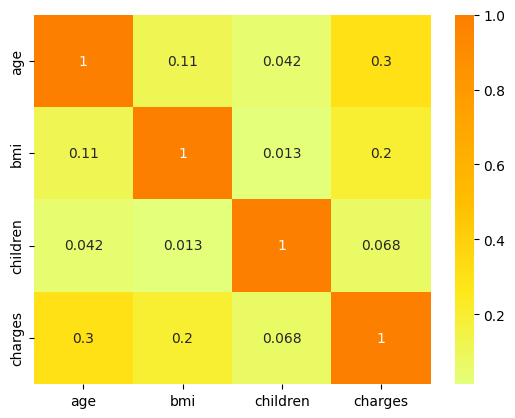

In [7]:
fields = []
df["children"] = df["children"].astype(int)
for i in df.columns:
    if (df[i].dtype == float or df[i].dtype == int):
        fields.append(i)
#print(fields)
df_numerical = df[fields]
df_numerical_corr = df_numerical.corr()
sns.heatmap(data = df_numerical_corr, cmap = "Wistia", annot = True);

## Check the distribution of insurance charges

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_86196\43630874.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['charges'], bins = 50, color = 'r', ax = ax);
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_86196\43630874.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.log10(df["charges"]), 

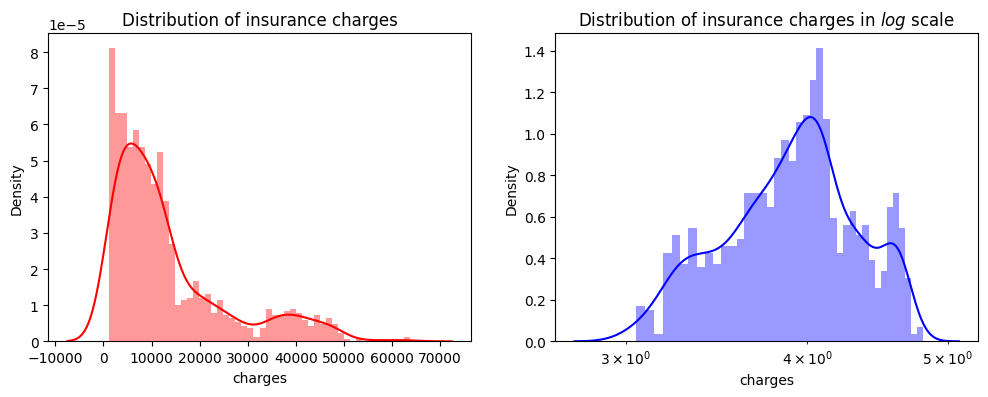

In [10]:
f = plt.figure(figsize = (12,4));

ax = f.add_subplot(121);
sns.distplot(df['charges'], bins = 50, color = 'r', ax = ax);
ax.set_title("Distribution of insurance charges");

ax = f.add_subplot(122);
sns.distplot(np.log10(df["charges"]), bins = 40, color = 'b', ax = ax);
ax.set_title('Distribution of insurance charges in $log$ scale');
ax.set_xscale('log');

As shown in the left graph, the distribution is left-skewed. Under this condition, the regression model places emphasis on the lower y-range. Then, the best-fit line can't predict the higher y-values correctly.

To fix it, we use $log$ in order to expand the lower value of the distribution and compress the higher value.

### Check the distribution between charges vs sex and charges vs smoker

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_86196\191894551.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data = df, x = 'sex', y = 'charges', palette = 'Wistia', ax = ax)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_86196\191894551.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data = df, x = 'smoker', y = 'charges', palette = 'magma', ax = ax)


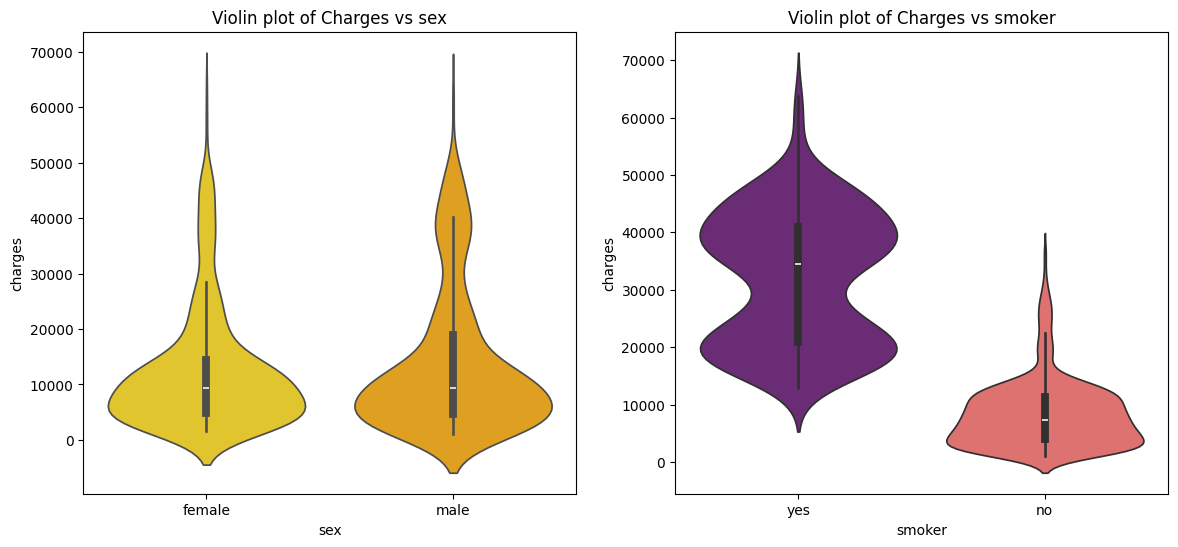

In [12]:
f = plt.figure(figsize = (14,6))
ax = f.add_subplot(121)
sns.violinplot(data = df, x = 'sex', y = 'charges', palette = 'Wistia', ax = ax)
ax.set_title('Violin plot of Charges vs sex')

ax = f.add_subplot(122)
sns.violinplot(data = df, x = 'smoker', y = 'charges', palette = 'magma', ax = ax)
ax.set_title('Violin plot of Charges vs smoker');

The violin plots show that males and females share a similar range and distribution of charges.

However, smokers and non-smokers are clearly different: smokers have a wider spread of charges (5000-70000) and a higher average, whereas non-smokers are concentrated in a lower range (0-40000)

### Check the distribution between charges vs children

Text(0.5, 1.0, 'Box plot of charges vs children')

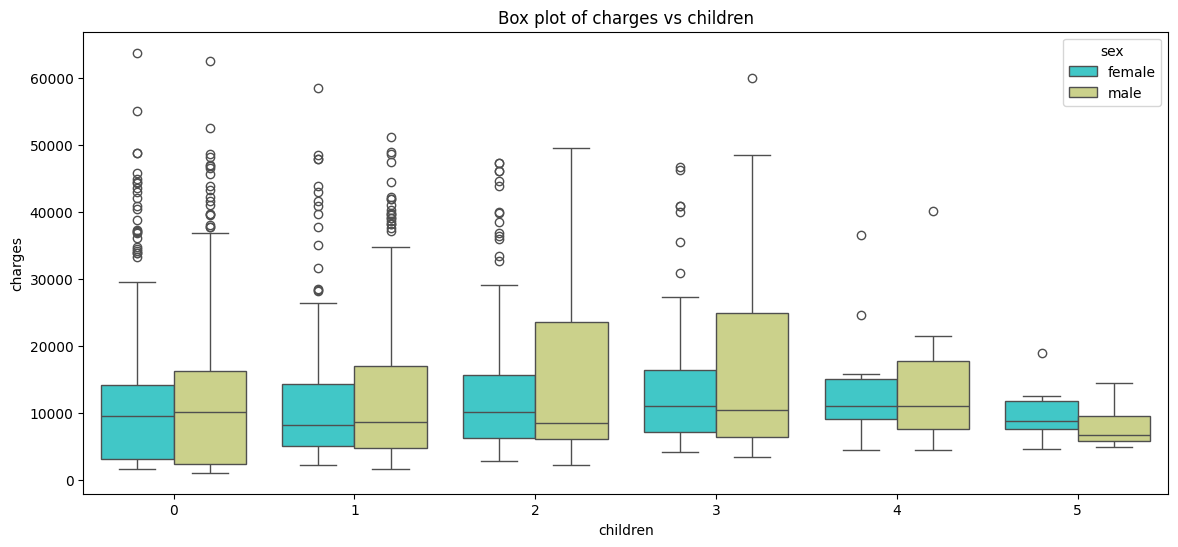

In [66]:
plt.figure (figsize = (14,6))
sns.boxplot(x = 'children', y = 'charges', hue = 'sex', data = df, palette = 'rainbow')
plt.title('Box plot of charges vs children')

We can see that the median of each group does not change much. Therefore, this factor has little effect on the linear regression model.

In [13]:
#agg = aggregate
df['charges'] = df['charges'].astype(float)
df.groupby('children').agg(['min','max'])['charges']

,min,max
children,,
0,1121.8739,63770.42801
1,1711.0268,58571.07448
2,2304.0022,49577.66240
3,3443.0640,60021.39897
4,4504.6624,40182.24600
5,4687.7970,19023.26000


Like the statement above, the number of children doesn't effect on the linear model regression

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_82604\3123470800.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data = df, x = 'region', y = 'charges', palette = 'rainbow')


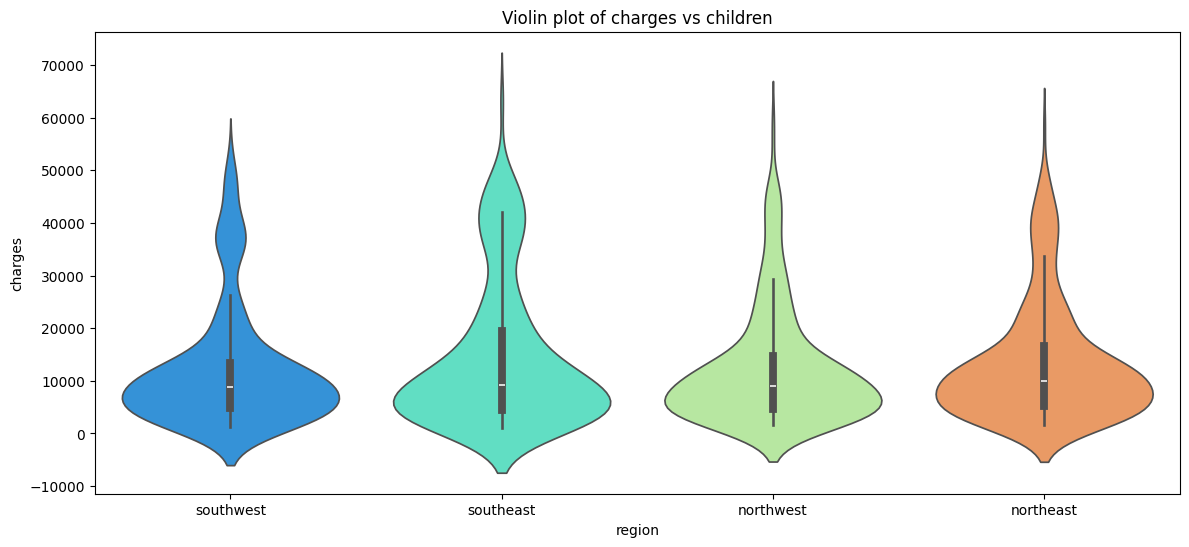

In [19]:
plt.figure(figsize = (14,6))
sns.violinplot(data = df, x = 'region', y = 'charges', palette = 'rainbow')
plt.title('Violin plot of charges vs children');

## Distribution of Charges vs age and Charges vs BMI

Text(0.5, 1.0, 'Scatter plot of Charges vs BMI')

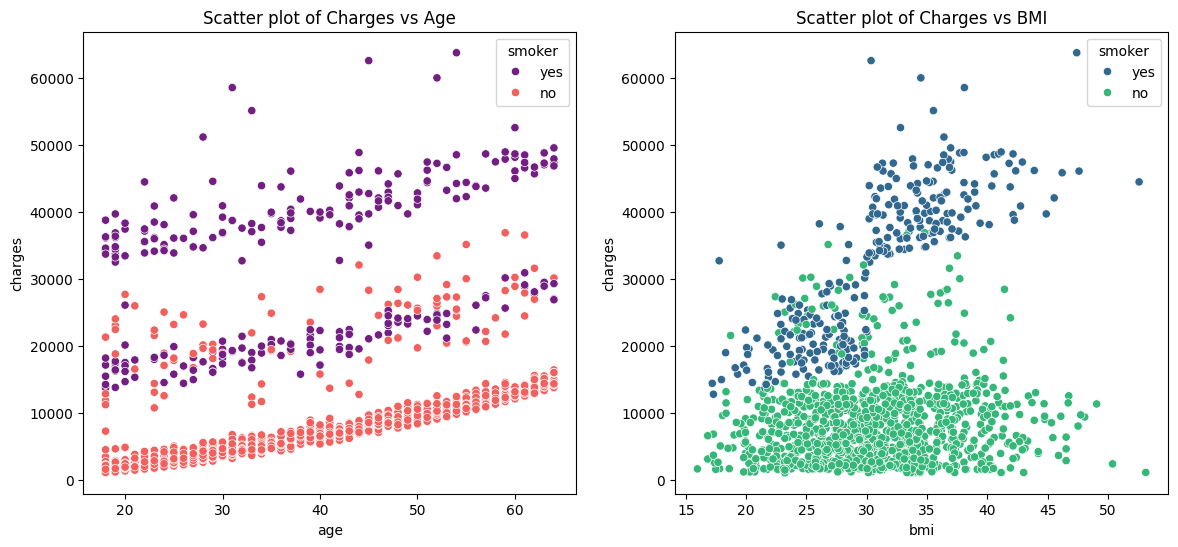

In [40]:
f = plt.figure(figsize = (14,6))
ax = f.add_subplot(121)
sns.scatterplot(data = df, x = 'age', y = 'charges', palette = 'magma', hue = 'smoker', ax = ax);
ax.set_title('Scatter plot of Charges vs Age')

ax = f.add_subplot(122)
sns.scatterplot(data = df, x= 'bmi', y = 'charges', palette = 'viridis', hue = 'smoker', ax = ax);
ax.set_title('Scatter plot of Charges vs BMI')

From the left plot, the minimum age person is insured is 18 years old. There is slabs in policy most of non smoker take $1^{st}$ and $2^{nd}$ slab, for smoker policy start at $2^{nd}$ and $3_=^{rd}$ slab.

It means that smokers tend to be older than non-smokers.

Besides, we can see the range of BMI index is from $16kg/m^{2}$ to $54kg/m^{2}$

## Data Preprocessing

### Encoding

Machine Learning algorithms cannot work with categorical data directly.  
So, categorical variables must be converted to numbers.

1. **Label Encoding**  
2. **One-Hot Encoding**  
3. **Dummy Variable Trap**

---

### **Label Encoding**

Label Encoding refers to transforming word labels into **numerical** form so that algorithms can operate on them.

Example:

$$
\begin{aligned}
\text{southeast} &\rightarrow 0 \\
\text{southwest} &\rightarrow 1 \\
\text{northwest} &\rightarrow 2
\end{aligned}
$$

---

### **One-Hot Encoding**

A One-Hot Encoding converts a **text category** into a number,  
and then converts that number into a binary vector that contains only \(0\)s and \(1\)s.

Example:

$$
\begin{aligned}
\text{southeast} &\rightarrow 0 \\
\text{southwest} &\rightarrow 1 \\
\text{northwest} &\rightarrow 2
\end{aligned}
$$

After One-Hot Encoding:

$$
\begin{aligned}
0 &\rightarrow [1, 0, 0] \\
1 &\rightarrow [0, 1, 0] \\
2 &\rightarrow [0, 0, 1]
\end{aligned}
$$

---

### **Dummy variable trap**

This is a scenario in which the independent variable are multicollinear, a scenario in which two or more variables multicollinear, a scenario in which two or more variables are highly correlated in simple term one variable can be predicted from the others.

Example:


$$
\begin{aligned}
0 &\rightarrow [1, 0, 0] \\
1 &\rightarrow [0, 1, 0] \\
2 &\rightarrow [0, 0, 1]
\end{aligned}
$$

    Then, if

$$ {X} = \begin{pmatrix}
        1 & 0 & 0 \\
        0 & 1 & 0 \\
        0 & 0 & 1 \\
        \end{pmatrix} $$

Column $1$ stands for $\text{southeast}$

Column $2$ stands for $\text{southwest}$

Column $3$ stands for $\text{northwest}$

We can see that $\text{southeast} + \text{southwest} + \text{northwest} = 1$. Therefore, we can calculate one variable from others. 

So, this will make our system of equations become $\text{linearly dependent system}$

By using $\text{get_dummies}$ function from $\text{pandas}$, we can fix it in one line of code. Like in this project, we use this function to get dummy variable for $\text{sex, children, smoker, and region}$. By using $\text{drop_first = True}$, function will remove dummy variable trap by droping one variable and original variable (like in the example above, we will remove $\text{region}$ and $\text{southeast}$).

In [8]:
# Dummy variable
categorical_columns = ['sex', 'children', 'smoker', 'region']
df_encode = pd.get_dummies(data = df, prefix = 'OHE', prefix_sep = '_',
                          columns = categorical_columns,
                          drop_first = True,
                          dtype = 'int8') #use int8 because it's enough to store data

In [9]:
# Verify the dummy variable process
print("Columns in original data frame: ", df.columns.values)
print("Shape of the dataset", df.shape)
print("Columns in data frame after encoding dummy variables: ", df_encode.columns.values) #use .values to convert data from Index object to numpy array (to make data more clearly)
print("Shape of the new dataset", df_encode.shape)

Columns in original data frame:  ['age' 'sex' 'bmi' 'children' 'smoker' 'region' 'charges']
Shape of the dataset (1338, 7)
Columns in data frame after encoding dummy variables:  ['age' 'bmi' 'charges' 'OHE_male' 'OHE_1' 'OHE_2' 'OHE_3' 'OHE_4' 'OHE_5'
 'OHE_yes' 'OHE_northwest' 'OHE_southeast' 'OHE_southwest']
Shape of the new dataset (1338, 13)


## Box-cox transformation

A Box Cox transformation is a way to transform non-normal dependent variables into a normal shape. Applying a Box-Cox means that you are able to run a broader number of tests. All that we need to perform this transformation is to find $\text{Lambda}$ value and apply the rule shown below to your variable:

$$
y_i^{(\lambda)} =
\begin{cases}
\dfrac{y_i^\lambda - 1}{\lambda}, & \lambda \neq 0, \\[6pt]
\log(y_i), & \lambda = 0.
\end{cases}
$$

In [12]:
from scipy.stats import boxcox
y_bc, lam, ci = boxcox(df_encode['charges'], alpha = 0.05)

# y_bc = y after use box-cox
# lam = the best lambda value
# ci = confidence interval (in this range, the precise of lambda = alpha)

ci, lam

((-0.011402906172930048, 0.09880968597671798),
 np.float64(0.043649061187374535))

In [56]:
## Log transform
df_encode['charges'] = np.log(df_encode['charges'])

## Train Test Split

In [57]:
from sklearn.model_selection import train_test_split
X = df_encode.drop('charges', axis = 1) #delete column
y = df_encode['charges']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.3, random_state = 23)

## Model Building

We build model using the linear regression equation

$$\theta = (X^{T}X)^{-1}X^{T}y$$

In [67]:
#Solution 01: Don't use sklearn 

# Step 1: add x0 =1 to dataset
X_train_0 = np.c_[np.ones((X_train.shape[0],1)),X_train]
X_test_0 = np.c_[np.ones((X_test.shape[0],1)),X_test]

# Step2: build model
theta = np.matmul(np.linalg.inv( np.matmul(X_train_0.T,X_train_0) ), np.matmul(X_train_0.T,y_train)) 

#Step 3: Print parameter 
parameter = []
for i in range (X_train_0.shape[1]):
    parameter.append('theta_' + str(i))
columns = ['intersect: x_0 = 1'] + list(X.columns.values)
#columns
#print(len(parameter), len(columns), len(theta))
parameter_df = pd.DataFrame({'Parameter': parameter, 'Columns': columns, 'theta': theta})
parameter_df

,Parameter,Columns,theta
0,theta_0,intersect: x_0 = 1,7.059171
1,theta_1,age,0.033134
2,theta_2,bmi,0.013517
3,theta_3,OHE_male,-0.067767
4,theta_4,OHE_1,0.149457
5,theta_5,OHE_2,0.272919
6,theta_6,OHE_3,0.244095
7,theta_7,OHE_4,0.523339
8,theta_8,OHE_5,0.466030
9,theta_9,OHE_yes,1.550481


In [68]:
#Solution 02: Use Sklearn
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

sk_theta = [lin_reg.intercept_] + list(lin_reg.coef_) #.intercept_ is theta_0; lin_reg.coef_ is theta_1, theta_2,...., theta_n
parameter_df = parameter_df.join(pd.Series(sk_theta, name = "Sklearn_theta"))
parameter_df

,Parameter,Columns,theta,Sklearn_theta
0,theta_0,intersect: x_0 = 1,7.059171,7.059171
1,theta_1,age,0.033134,0.033134
2,theta_2,bmi,0.013517,0.013517
3,theta_3,OHE_male,-0.067767,-0.067767
4,theta_4,OHE_1,0.149457,0.149457
5,theta_5,OHE_2,0.272919,0.272919
6,theta_6,OHE_3,0.244095,0.244095
7,theta_7,OHE_4,0.523339,0.523339
8,theta_8,OHE_5,0.466030,0.466030
9,theta_9,OHE_yes,1.550481,1.550481


## Model evaluation

We need to compare the predicted value with the actual value in test set. So, we compute $\text{Mean Square Error}$ using formula

$$ J(\theta) = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i-y_i)^2$$

$R^{2}$ is statistical measure of how close data are to the fitted regression line. $R^{2}$ is always between $0$ and $100%$. In this case, $0%$ indicated that model explains none of the variability of the response data around it's mean (aka all prediction equal to mean). $100%$ indicated that model explains all the variability of the response data around the mean (aka "Excellence" )

$$R^2 = 1 - \frac{\text{SSE}}{\text{SST}}$$
$$\text{SSE} = \sum_{i=1}^{m} (\hat{y}_i - y_i)^2$$
$$\text{SST} = \sum_{i=1}^{m} (y_i - \bar{y})^2 $$

$\text{SSE}$ = Sum of Square Error

$\text{SST}$ = Sum of Square Total

In [69]:
#Normal Equation
y_pred_norm = np.matmul(X_test_0, theta)

#Evaluation: MSE
J_mse = np.sum((y_pred_norm - y_test)**2)/X_test_0.shape[0]

#R_square
sse = np.sum((y_pred_norm - y_test)**2)
sst = np.sum((y_test - y_test.mean())**2)
R_square = 1- (sse/sst)
print("The Mean Square Error (MSE) of J(theta) is: ", J_mse)
print("R_square obtain for normal equation method is: ", R_square)

The Mean Square Error (MSE) of J(theta) is:  0.1872962232298195
R_square obtain for normal equation method is:  0.7795687545055312


In [70]:
#Using Sklearn to calculate MSE, R_square
y_pred_sk = lin_reg.predict(X_test)

#Evaluation: MSE
from sklearn.metrics import mean_squared_error
J_mse_sk = mean_squared_error(y_pred_sk, y_test)

#R_square
R_square_sk = lin_reg.score(X_test, y_test)

print("The Mean Square Error (MSE) of J(theta) is: ", J_mse_sk)
print("R_square obtain for normal equation method is: ", R_square_sk)

The Mean Square Error (MSE) of J(theta) is:  0.18729622322981898
R_square obtain for normal equation method is:  0.7795687545055318


In [74]:
Answer = pd.DataFrame({"Answer": y_pred_sk, "Check": y_test})
Answer

,Answer,Check
918,9.328027,9.475924
755,8.665157,8.523428
207,10.349459,9.951520
520,9.085704,10.152555
695,8.407991,8.071295
...,...,...
1302,8.184626,8.073648
1191,8.861191,9.527009
1085,10.481768,9.853418
663,7.896219,7.035620
